# **Amazon UK Product Analysis - Bivariate EDA**

#### **By: Paulina Mamiaga**

-----------------

## **1. Objective**

The objective of this analysis is to explore relationships between key product variables in the Amazon UK marketplace, with a focus on best-seller status, pricing, categories, brands, and customer ratings.

From a business perspective, this study aims to identify patterns that can support category strategy, pricing decisions, and product positioning.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency, pearsonr, probplot
from scipy.stats.contingency import association

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

current_dir = os.getcwd()

while not os.path.exists(os.path.join(current_dir, "data", "raw")):
    parent = os.path.dirname(current_dir)
    if parent == current_dir:
        raise FileNotFoundError("Project root with data/raw not found")
    current_dir = parent

os.chdir(current_dir)

df = pd.read_csv("data/raw/amz_uk_price_prediction_dataset.csv")
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2443651 entries, 0 to 2443650
Data columns (total 9 columns):
 #   Column             Dtype  
---  ------             -----  
 0   uid                int64  
 1   asin               object 
 2   title              object 
 3   stars              float64
 4   reviews            int64  
 5   price              float64
 6   isBestSeller       bool   
 7   boughtInLastMonth  int64  
 8   category           object 
dtypes: bool(1), float64(2), int64(3), object(3)
memory usage: 151.5+ MB


,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


## **2. Part 1: Analyzing Best-Seller Trends Across Product Categories**

### **2.1.1. Crosstab**

In [2]:
crosstab_cat_bestseller = pd.crosstab(df["category"], df["isBestSeller"])
crosstab_cat_bestseller.head()

isBestSeller,False,True
category,,
3D Printers,247,1
3D Printing & Scanning,4065,2
Abrasive & Finishing Products,245,5
Action Cameras,1696,1
Adapters,251,3


### **2.1.2. Proportion of best-sellers by category**

In [3]:
best_seller_prop = (
    pd.crosstab(df["category"], df["isBestSeller"], normalize="index") * 100
)

best_seller_prop = best_seller_prop.rename(columns={False: "not_best_seller_pct", True: "best_seller_pct"})
best_seller_prop = best_seller_prop.sort_values("best_seller_pct", ascending=False)

best_seller_prop.head(10)

isBestSeller,not_best_seller_pct,best_seller_pct
category,,
Grocery,94.186533,5.813467
Smart Home Security & Lighting,94.230769,5.769231
Health & Personal Care,94.231372,5.768628
Mobile Phone Accessories,95.752896,4.247104
Power & Hand Tools,96.466105,3.533895
"Billiard, Snooker & Pool",96.787149,3.212851
Pet Supplies,96.979972,3.020028
Home Brewing & Wine Making,97.154472,2.845528
Mirrors,97.200000,2.800000


### **2.1.3. Chi-square test**

In [4]:
chi2, p, dof, expected = chi2_contingency(crosstab_cat_bestseller)
print("Chi-square statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

Chi-square statistic: 36540.20270061387
p-value: 0.0
Degrees of freedom: 295


### **2.1.4. Cramér’s V**

In [5]:
cramers_v = association(crosstab_cat_bestseller, method="cramer")
print("Cramér's V:", cramers_v)

Cramér's V: 0.1222829439760564


### **2.1.5. Stacked bar chart**

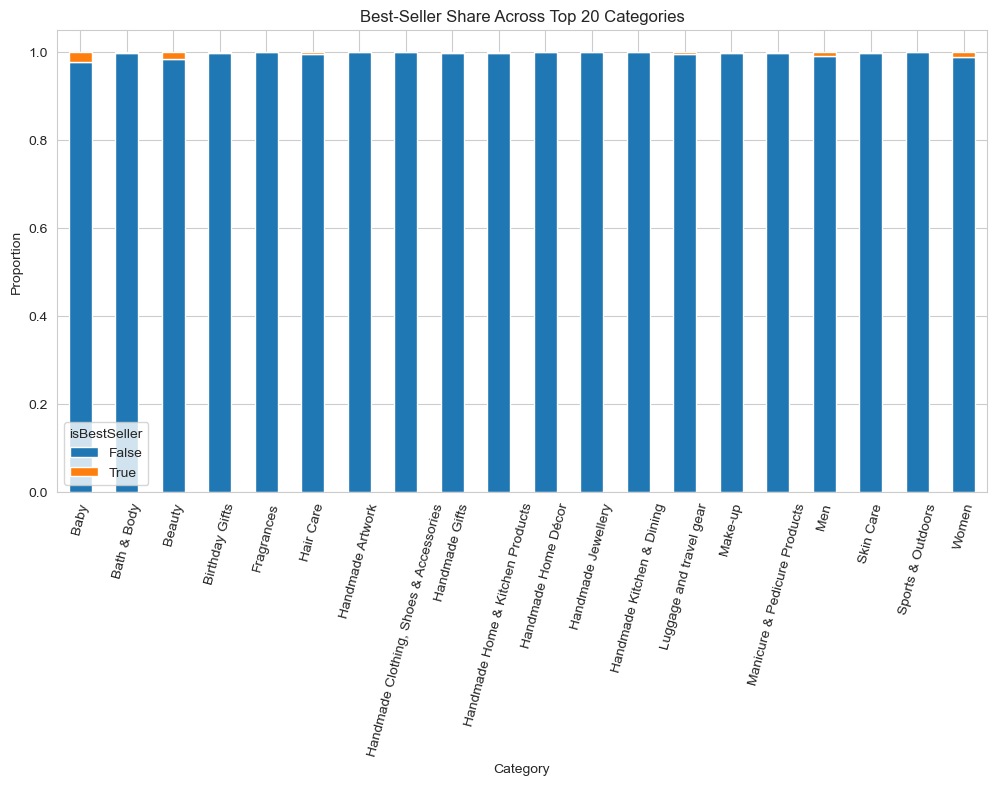

In [6]:
top20_categories = df["category"].value_counts().head(20).index
df_top20 = df[df["category"].isin(top20_categories)]

stacked_data = pd.crosstab(df_top20["category"], df_top20["isBestSeller"], normalize="index")
stacked_data.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Best-Seller Share Across Top 20 Categories")
plt.ylabel("Proportion")
plt.xlabel("Category")
plt.xticks(rotation=75)
plt.legend(title="isBestSeller")
plt.show()

## **3. Part 2: Exploring Product Prices and Ratings Across Categories and Brands**

### **3.2.1. Remove outliers with IQR**

In [7]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_no_outliers = df[(df["price"] >= lower_bound) & (df["price"] <= upper_bound)].copy()

print("Original rows:", len(df))
print("Rows without outliers:", len(df_no_outliers))
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Original rows: 2443651
Rows without outliers: 2115963
Lower bound: -44.01
Upper bound: 99.99000000000001


### **3.2.2. Top 20 categories by count**

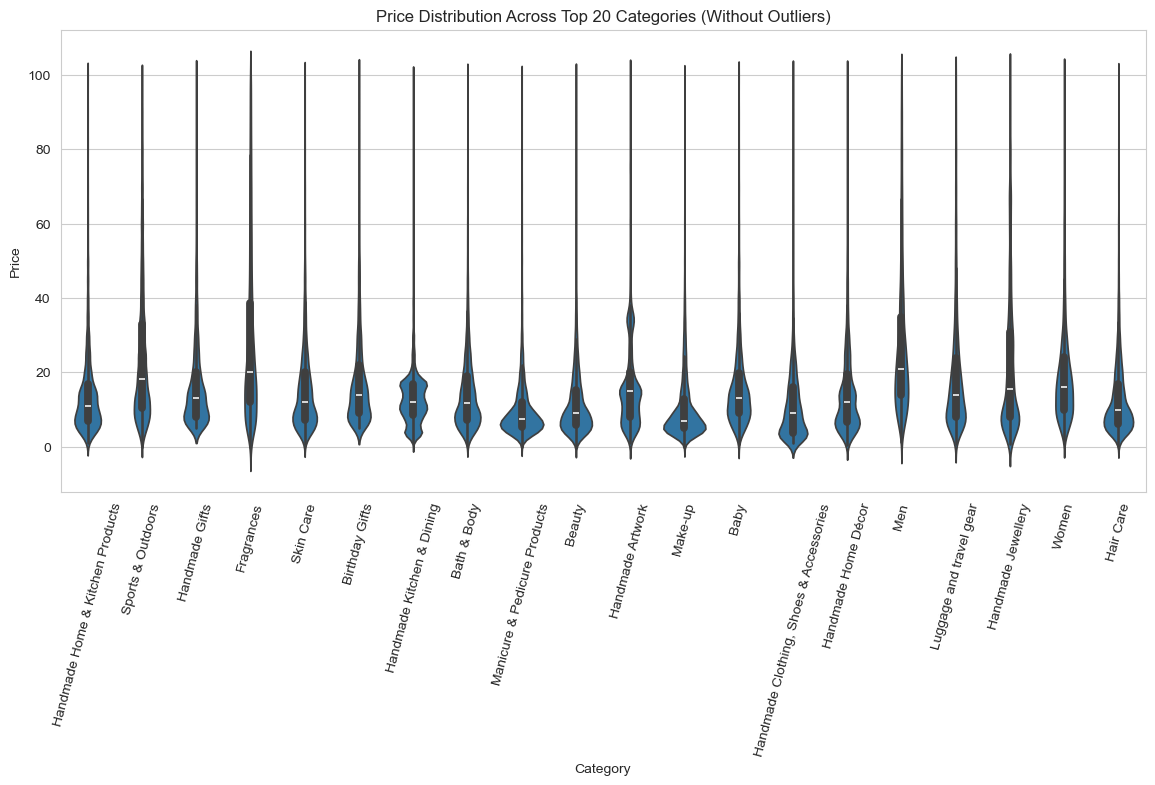

In [8]:
top20_categories = df_no_outliers["category"].value_counts().head(20).index
df_top20_no_outliers = df_no_outliers[df_no_outliers["category"].isin(top20_categories)]

plt.figure(figsize=(14, 6))
sns.violinplot(data=df_top20_no_outliers, x="category", y="price")
plt.xticks(rotation=75)
plt.title("Price Distribution Across Top 20 Categories (Without Outliers)")
plt.xlabel("Category")
plt.ylabel("Price")
plt.show()

### **3.2.3. Highest Median Price Category**

In [9]:
category_median_price = (
    df_no_outliers.groupby("category")["price"]
    .median()
    .sort_values(ascending=False)
)

category_median_price.head(10)

category
Desktop PCs               74.00
Boxing Shoes              69.79
Tablets                   69.00
Graphics Cards            68.54
Motherboards              67.92
Made in Italy Handmade    64.00
Digital Frames            63.90
Streaming Clients         62.68
Golf Shoes                62.39
Ski Helmets               61.33
Name: price, dtype: float64

### **3.2.4. Bar chart of average price for top 10 categories by count**

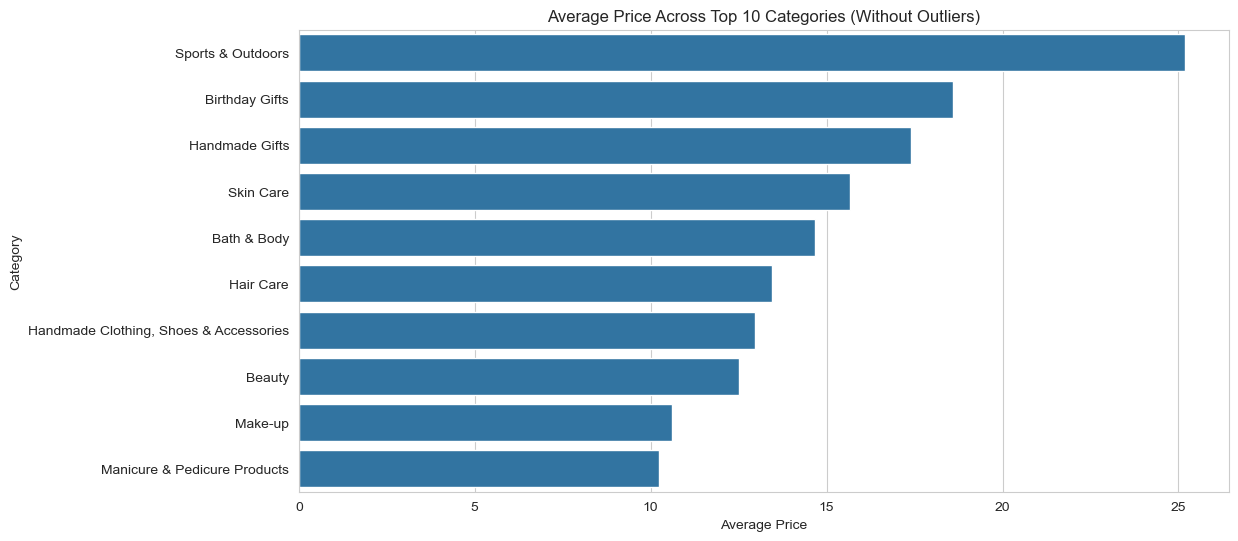

In [10]:
top10_categories = df_no_outliers["category"].value_counts().head(10).index
avg_price_top10 = (
    df_no_outliers[df_no_outliers["category"].isin(top10_categories)]
    .groupby("category")["price"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))
sns.barplot(x=avg_price_top10.values, y=avg_price_top10.index)
plt.title("Average Price Across Top 10 Categories (Without Outliers)")
plt.xlabel("Average Price")
plt.ylabel("Category")
plt.show()

### **3.2.5. Highest Average Price**

In [11]:
category_avg_price = (
    df_no_outliers.groupby("category")["price"]
    .mean()
    .sort_values(ascending=False)
)

category_avg_price.head(10)

category
Motherboards         68.772432
Boxing Shoes         67.417803
Desktop PCs          66.915562
Tablets              66.552971
Graphics Cards       65.103509
Digital Frames       60.745129
Streaming Clients    60.241803
Hockey Shoes         60.094796
Computer Cases       58.339884
Skiing Poles         57.867770
Name: price, dtype: float64

### **3.2.6. Top 10 Categories By Count**

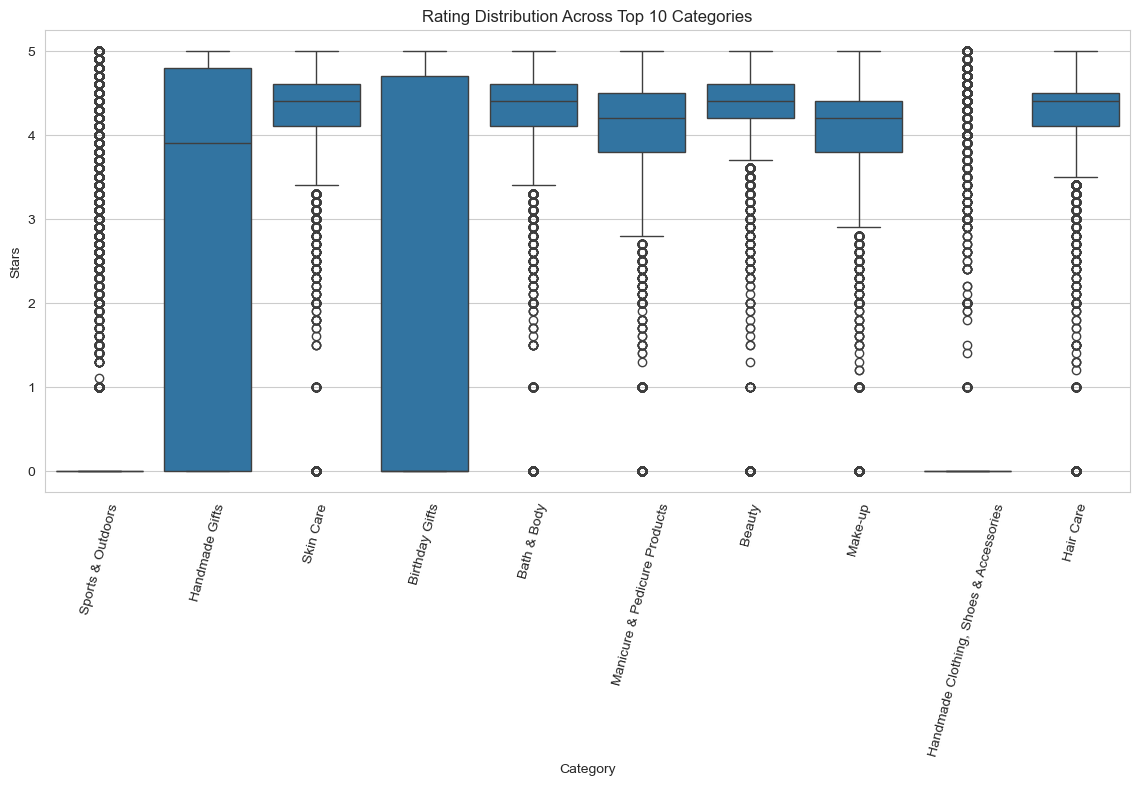

In [12]:
top10_categories = df_no_outliers["category"].value_counts().head(10).index
df_top10_no_outliers = df_no_outliers[df_no_outliers["category"].isin(top10_categories)]

plt.figure(figsize=(14, 6))
sns.boxplot(data=df_top10_no_outliers, x="category", y="stars")
plt.xticks(rotation=75)
plt.title("Rating Distribution Across Top 10 Categories")
plt.xlabel("Category")
plt.ylabel("Stars")
plt.show()

### **3.2.7. Highest Median Rating**

In [13]:
category_median_rating = (
    df_no_outliers.groupby("category")["stars"]
    .median()
    .sort_values(ascending=False)
)

category_median_rating.head(10)

category
Computer Memory                 4.7
Beer, Wine & Spirits            4.6
Building & Construction Toys    4.6
Office Paper Products           4.6
Kids' Play Figures              4.6
Laptop Accessories              4.6
Hobbies                         4.6
Luxury Food & Drink             4.6
Soft Toys                       4.5
Boxes & Organisers              4.5
Name: stars, dtype: float64

## **4. Part 3: Investigating the Interplay Between Product Prices and Ratings**

### **4.3.1. Correlation Coefficient**

In [14]:
corr_price_stars = df_no_outliers["price"].corr(df_no_outliers["stars"])
print("Correlation between price and stars:", corr_price_stars)

pearson_corr, pearson_p = pearsonr(df_no_outliers["price"], df_no_outliers["stars"])
print("Pearson correlation:", pearson_corr)
print("p-value:", pearson_p)

Correlation between price and stars: -0.0776729987818137
Pearson correlation: -0.07767299878181355
p-value: 0.0


### **4.3.2. Scatter Plot**

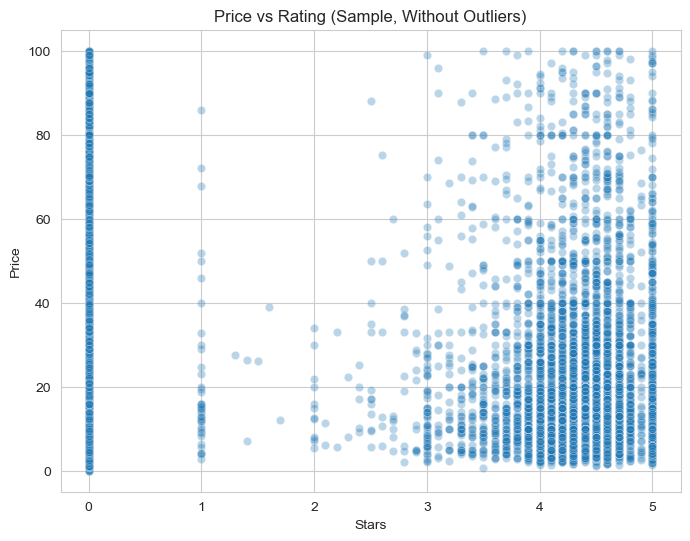

In [15]:
sample_df = df_no_outliers.sample(10000, random_state=42)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=sample_df, x="stars", y="price", alpha=0.3)
plt.title("Price vs Rating (Sample, Without Outliers)")
plt.xlabel("Stars")
plt.ylabel("Price")
plt.show()

### **4.3.3. Correlation heatmap**

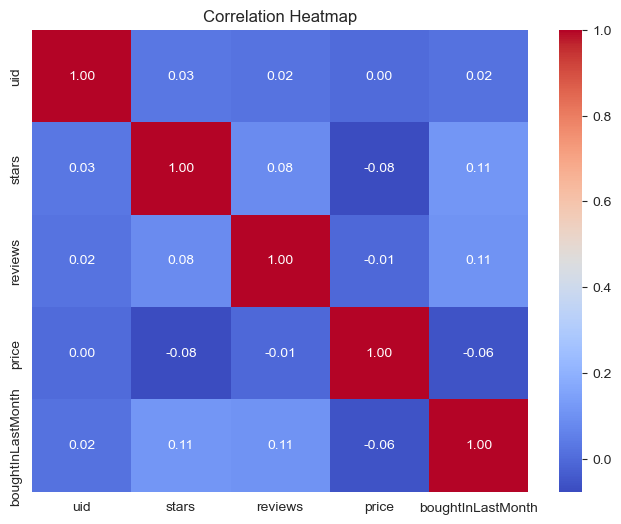

In [16]:
numeric_cols = df_no_outliers.select_dtypes(include=[np.number]).columns
corr_matrix = df_no_outliers[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

### **4.3.4. QQ Plot For Price**

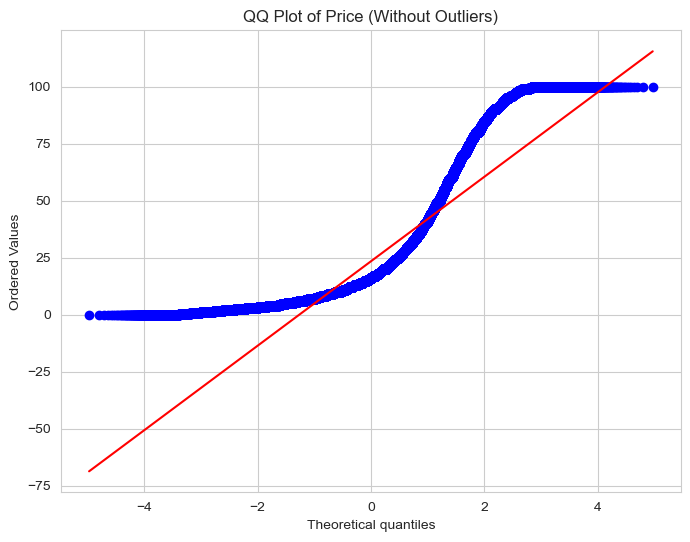

In [17]:
plt.figure(figsize=(8, 6))
probplot(df_no_outliers["price"], dist="norm", plot=plt)
plt.title("QQ Plot of Price (Without Outliers)")
plt.show()

### **4.3.5. Same Analysis With Outliers**

In [18]:
corr_with_outliers = df["price"].corr(df["stars"])
corr_without_outliers = df_no_outliers["price"].corr(df_no_outliers["stars"])

print("Correlation with outliers:", corr_with_outliers)
print("Correlation without outliers:", corr_without_outliers)

Correlation with outliers: -0.1249067326214861
Correlation without outliers: -0.0776729987818137
